# Decision Trees — Classification and Regression

This notebook implements the workflows described in `notes.md`:

1. `DecisionTreeClassifier` on `load_breast_cancer`, visualized with `plot_tree`, comparing an **unpruned** tree vs. a **depth-limited** tree (accuracy comparison).
2. `DecisionTreeRegressor` on `fetch_california_housing`, reporting RMSE.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

%matplotlib inline

## 1) Decision Tree Classification: Breast Cancer

We fit two `DecisionTreeClassifier`s on the same train/test split:

- An **unpruned** tree (`max_depth=None`) grown until every leaf is pure or `min_samples_split` is hit — expected to overfit the training set.
- A **depth-limited** tree (`max_depth=3`) — a pre-pruned, simpler tree.

We compare their train/test accuracy and visualize both with `plot_tree`.

In [2]:
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

unpruned = DecisionTreeClassifier(random_state=42)
unpruned.fit(X_train, y_train)

pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned.fit(X_train, y_train)

for name, model in [("Unpruned", unpruned), ("Depth-limited (max_depth=3)", pruned)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: depth={model.get_depth()}, leaves={model.get_n_leaves()}, "
          f"train acc={train_acc:.4f}, test acc={test_acc:.4f}")

Unpruned: depth=6, leaves=16, train acc=1.0000, test acc=0.9181
Depth-limited (max_depth=3): depth=3, leaves=7, train acc=0.9799, test acc=0.9240


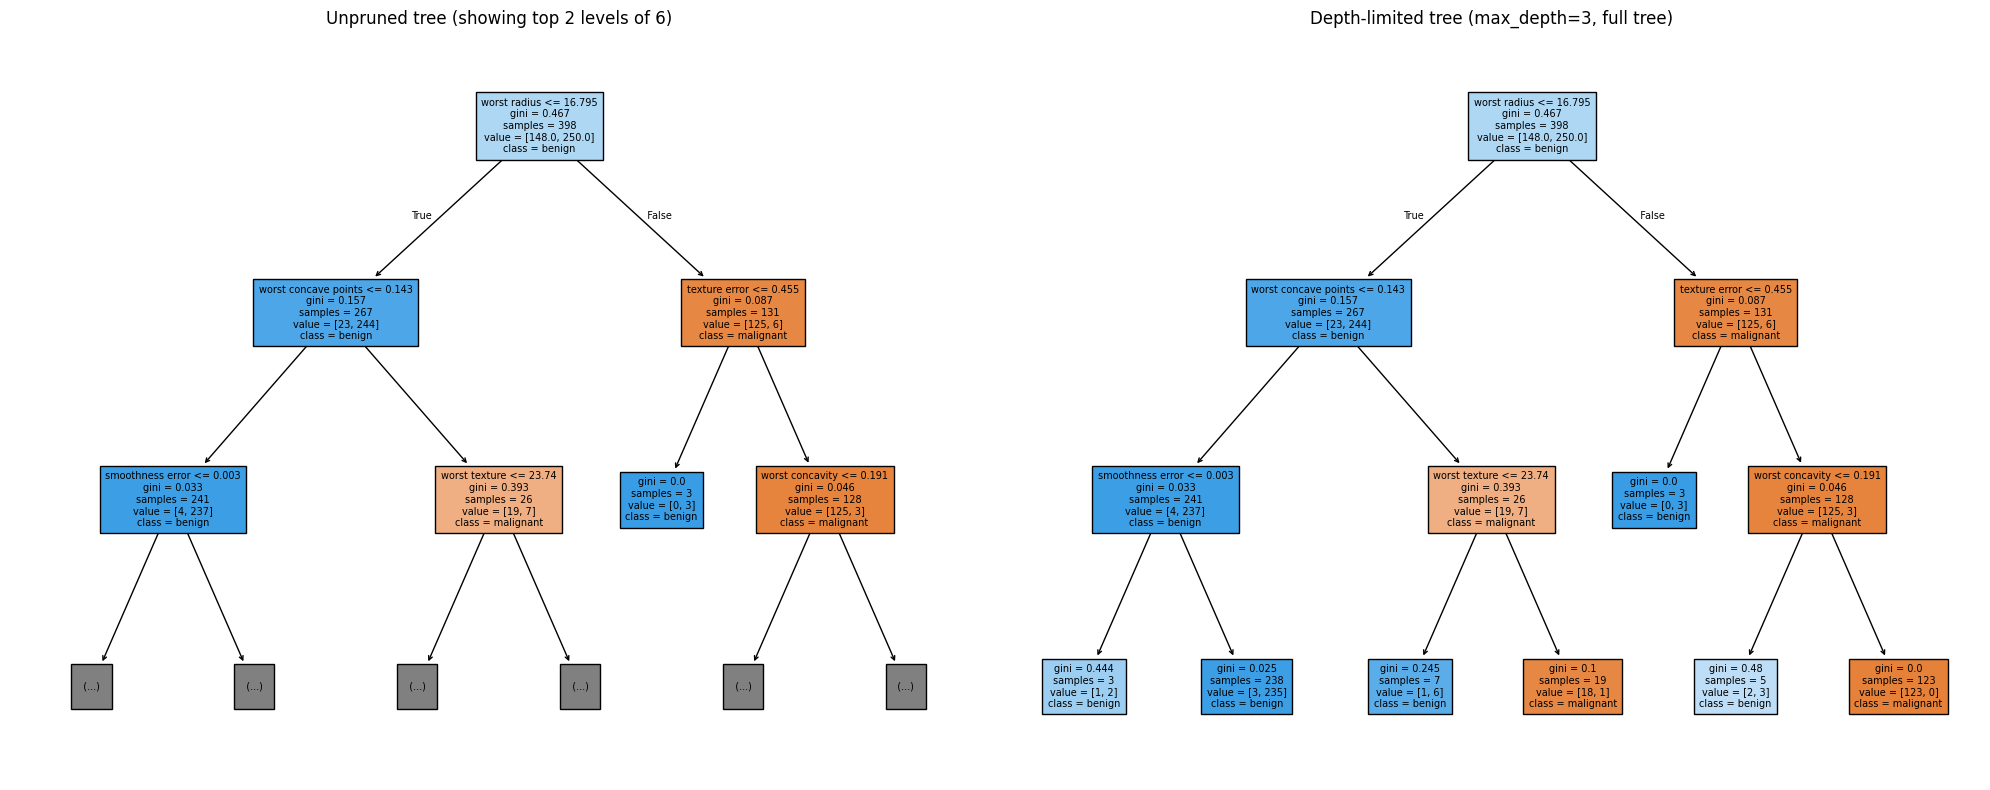

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_tree(
    unpruned, ax=axes[0], max_depth=2, feature_names=cancer.feature_names,
    class_names=cancer.target_names, filled=True, fontsize=7,
)
axes[0].set_title(f"Unpruned tree (showing top 2 levels of {unpruned.get_depth()})")

plot_tree(
    pruned, ax=axes[1], feature_names=cancer.feature_names,
    class_names=cancer.target_names, filled=True, fontsize=7,
)
axes[1].set_title("Depth-limited tree (max_depth=3, full tree)")

plt.tight_layout()
plt.show()

## 2) Decision Tree Regression: California Housing

`DecisionTreeRegressor` predicts the median house value by averaging the target of training samples that fall into the same leaf. We limit `max_depth` to avoid a hugely overfit tree, and report RMSE on a held-out test set.

In [4]:
housing = fetch_california_housing()
Xh, yh = housing.data, housing.target

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    Xh, yh, test_size=0.2, random_state=42
)

reg = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
reg.fit(Xh_train, yh_train)
yh_pred = reg.predict(Xh_test)

rmse = mean_squared_error(yh_test, yh_pred) ** 0.5
r2 = r2_score(yh_test, yh_pred)
print(f"DecisionTreeRegressor (max_depth=8): RMSE={rmse:.4f}, R\u00b2={r2:.4f}")

DecisionTreeRegressor (max_depth=8): RMSE=0.6459, R²=0.6816


## Takeaway

- The unpruned tree grows very deep and reaches (near-)perfect training accuracy but generalizes worse than the depth-limited tree — classic overfitting from an unconstrained, greedily-grown tree.
- The depth-limited tree (`max_depth=3`) trades a little training accuracy for a smaller gap between train and test accuracy, and is small enough to read directly off the `plot_tree` diagram.
- For regression, constraining `max_depth`/`min_samples_leaf` on California Housing keeps the tree from memorizing individual training points, at the cost of coarser (staircase-like) predictions.